## Time series for priority vs. how long from Open to Closed

## Time series for escalation vs. how long from Open to Closed

## Pie Charts


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datetime import datetime

df_agg = pd.read_csv('df_agg.csv', parse_dates=['Opened', 'Closed'])
df_agg.head(3)

,Unnamed: 0,Assigned To,Assignment group,Closed,Configuration item,Escalation,Incident state,Opened,Opened.1,Priority,...,Updated,Opened timestamp,Closed timestamp,Updated timestamp,SLA timestamp,Opened_day,Opened_hour,duration,Closed_day,Closed_hour
0,0,Vinodh Sundareswaran,MCS Production Support,2018-01-03 11:32:31,"MCS Replenishments (E3, MPI, SAM, PO)",10,Closed,2018-01-01 09:24:33,2018-01-01 09:24:33,4,...,2018-01-03 11:32:31,2018-01-01 09:24:33,2018-01-03 11:32:31,2018-01-01 09:24:33,2018-01-04 09:24:33,0,9,2 days 02:07:58.000000000,2,11
1,1,Sangbida Dhar,MCS Production Support,2018-01-04 12:00:29,MCS Configuration,10,Closed,2018-01-02 03:25:26,2018-01-02 03:25:26,4,...,2018-01-04 12:00:29,2018-01-02 03:25:26,2018-01-04 12:00:29,2018-01-02 03:25:26,2018-01-05 03:25:26,1,3,2 days 08:35:03.000000000,3,12
2,2,Kiki Lam,MCS Production Support,2018-01-03 13:21:24,MCS SKU Mgmt/Pricing issues,3,Closed,2018-01-02 09:40:36,2018-01-02 09:40:36,2,...,2018-01-03 13:21:24,2018-01-02 09:40:36,2018-01-03 13:21:24,2018-01-02 09:40:36,2018-01-07 09:40:36,1,9,1 days 03:40:48.000000000,2,13


## Time series for priority vs. how long from Open to Closed

In [3]:
hm1 = df_agg[["Opened_day", "Opened_hour", 'Priority']]
hm1.head(3)

,Opened_day,Opened_hour,Priority
0,0,9,4
1,1,3,4
2,1,9,2


In [4]:
hm2 = hm1.groupby(by=['Opened_day','Opened_hour'], as_index=False).mean().rename(columns={"Assigned To": "count"})

In [5]:
hm2.head()

,Opened_day,Opened_hour,Priority
0,0,0,3.666667
1,0,1,3.692308
2,0,2,3.300000
3,0,3,3.652174
4,0,4,3.583333


In [6]:
hm3 = hm2.pivot(index='Opened_hour', columns='Opened_day', values='Priority')
hm3.head()

Opened_day,0,1,2,3,4,5,6
Opened_hour,,,,,,,
0,3.666667,3.666667,3.714286,4.000000,4.000000,3.000000,4.000000
1,3.692308,3.714286,4.000000,4.000000,3.166667,4.000000,NaN
2,3.300000,3.500000,3.636364,4.000000,3.714286,3.500000,6.000000
3,3.652174,4.000000,3.826087,3.793103,3.764706,2.666667,3.333333
4,3.583333,3.520000,3.458333,3.629630,3.724138,4.000000,3.428571


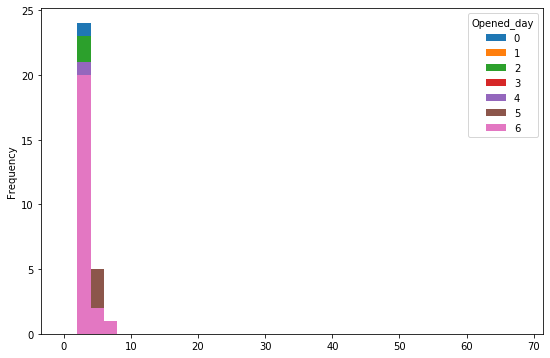

In [7]:
hm3.plot.hist(bins=np.arange(0, 70, 2), figsize=(9,6))

In [11]:
##The graph above shows the average priority for certain tasks based on how many days between being opened & closed.

## Time series for escalation vs. how long from Open to Closed

In [17]:
hm1_e = df_agg[["Opened_day", "Opened_hour", 'Escalation']]
hm1_e.head(3)

,Opened_day,Opened_hour,Escalation
0,0,9,10
1,1,3,10
2,1,9,3


In [18]:
hm2_e = hm1_e.groupby(by=['Opened_day','Opened_hour'], as_index=False).mean().rename(columns={"Assigned To": "count"})

In [19]:
hm2_e.head()

,Opened_day,Opened_hour,Escalation
0,0,0,4.083333
1,0,1,4.615385
2,0,2,4.400000
3,0,3,4.260870
4,0,4,5.000000


In [28]:
hm3_e = hm2_e.pivot(index='Opened_hour', columns='Opened_day', values='Escalation')
hm3_e.head()

Opened_day,0,1,2,3,4,5,6
Opened_hour,,,,,,,
0,4.083333,5.500000,5.571429,6.500000,6.777778,8.00,8.000000
1,4.615385,3.428571,7.500000,4.500000,3.750000,12.00,NaN
2,4.400000,4.875000,6.272727,5.769231,6.071429,8.75,6.333333
3,4.260870,5.866667,4.130435,5.172414,6.882353,10.00,4.000000
4,5.000000,7.200000,5.895833,7.000000,6.275862,9.25,8.714286


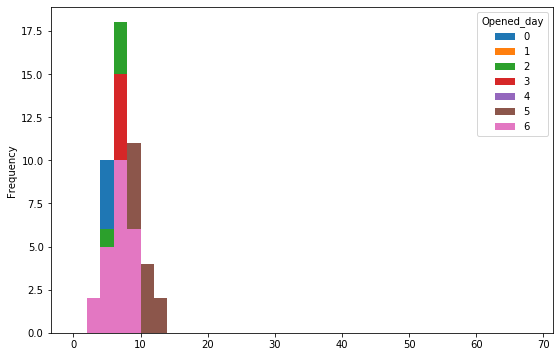

In [29]:
hm3_e.plot.hist(bins=np.arange(0, 70, 2), figsize=(9,6))

In [30]:
##The graph above shows the average escalation for certain tasks based on how many days between being opened & closed.

## Escalation/ Priority Pie Charts

In [31]:
data = df_agg

In [32]:
data.head(2)

,Unnamed: 0,Assigned To,Assignment group,Closed,Configuration item,Escalation,Incident state,Opened,Opened.1,Priority,...,Updated,Opened timestamp,Closed timestamp,Updated timestamp,SLA timestamp,Opened_day,Opened_hour,duration,Closed_day,Closed_hour
0,0,Vinodh Sundareswaran,MCS Production Support,2018-01-03 11:32:31,"MCS Replenishments (E3, MPI, SAM, PO)",10,Closed,2018-01-01 09:24:33,2018-01-01 09:24:33,4,...,2018-01-03 11:32:31,2018-01-01 09:24:33,2018-01-03 11:32:31,2018-01-01 09:24:33,2018-01-04 09:24:33,0,9,2 days 02:07:58.000000000,2,11
1,1,Sangbida Dhar,MCS Production Support,2018-01-04 12:00:29,MCS Configuration,10,Closed,2018-01-02 03:25:26,2018-01-02 03:25:26,4,...,2018-01-04 12:00:29,2018-01-02 03:25:26,2018-01-04 12:00:29,2018-01-02 03:25:26,2018-01-05 03:25:26,1,3,2 days 08:35:03.000000000,3,12


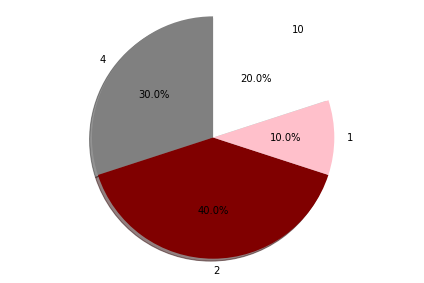

In [33]:
# Pie chart
labels = [4, 2, 1, 10]
sizes = [30, 40, 10, 20]
#add colors
colors = ['grey','maroon','pink','white']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')
plt.tight_layout()
plt.show()

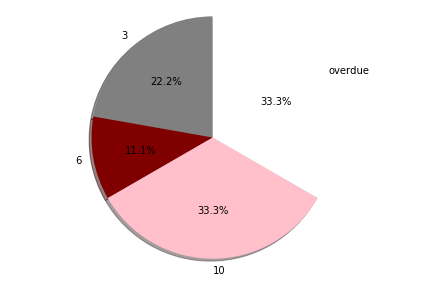

In [94]:
# Pie chart
labels = [3, 6, 10, 'overdue']
sizes = [20, 10, 30, 30]
#add colors
colors = ['grey','maroon','pink','white']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')
plt.tight_layout()
plt.show()